# M3/M5 — ACHPR Case Law Analysis

Analysis of the ACHPR case law dataset (30 cases) for Ch.3 (functional criterion emergence) and Ch.4 (doctrinal concepts, cross-system citations).

**Data sources:**
- `data/achpr_cases.json` — 30 coded ACHPR/African Court decisions
- `data/case_law_analysis.json` — doctrinal concepts + cross-system citations
- `src/data.js` — constitutional recognition data (for pre/post-Ogiek analysis)

**Thesis chapters served:** Ch.3 (functional criterion emergence), Ch.4 S1 (doctrinal concepts), Ch.4 S2 (cross-system citations), Ch.5 (self-determination evolution)

> **Methodological note:** The case law dataset is extracted from 3 docx files covering sessions 70-81 plus 2 landmark cases (Endorois, Ogiek) added manually. It is NOT exhaustive — it represents the cases Alex has analyzed so far. The functional criterion coding is preliminary and requires legal validation.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import re
from pathlib import Path
from collections import Counter

# Style
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': '#f6f3ee',
    'axes.facecolor': '#f6f3ee',
    'savefig.facecolor': '#f6f3ee',
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# Colors matching dashboard heritage palette
C_FRANCO = '#4a5a9a'  # indigo
C_ANGLO = '#9a3a4a'   # burgundy
C_LUSO = '#2a7a5a'    # forest green
C_OTHER = '#7a8088'   # slate
C_PEOPLES = '#c0392b' # red for peoples' rights cases
C_FUNC = '#e67e22'    # orange for functional criterion
C_MUTED = '#5e6a78'   # muted text
C_DIM = '#8a94a4'     # dim

FIG_DIR = Path('../data/figures')
FIG_DIR.mkdir(exist_ok=True)

# Load data
with open('../data/achpr_cases.json') as f:
    cases = json.load(f)

with open('../data/case_law_analysis.json') as f:
    analysis = json.load(f)

# Load constitutional data for pre/post-Ogiek
with open('../src/data.js') as f:
    raw = f.read()
    start = raw.index('{')
    end = raw.rindex('}') + 1
    DATA = json.loads(raw[start:end])

print(f'Cases: {len(cases)}')
print(f'Doctrinal concepts: {len(analysis["doctrinal_concepts"])}')
print(f'Cross-system citations: {len(analysis["cross_system_citations"])}')

Cases: 30
Doctrinal concepts: 14
Cross-system citations: 6


## 1. Data Preparation

Parse dates, extract filing years, classify cases by peoples' rights invocation.

In [2]:
# Extract filing year from case_number (e.g., 298/05 -> 2005, 006/2012 -> 2012)
def parse_filing_year(case_num):
    parts = case_num.split('/')
    if len(parts) == 2:
        yr = parts[1]
        if len(yr) == 2:
            return 2000 + int(yr) if int(yr) < 50 else 1900 + int(yr)
        elif len(yr) == 4:
            return int(yr)
    return None

# Parse decision year from date field
def parse_decision_year(date_str):
    if not date_str:
        return None
    # Try just year
    m = re.search(r'\b(19|20)\d{2}\b', date_str)
    return int(m.group()) if m else None

# Build DataFrame
rows = []
for c in cases:
    filing_yr = parse_filing_year(c['case_number'])
    decision_yr = parse_decision_year(c.get('date', ''))
    peoples_arts = [a.strip() for a in c.get('peoples_articles', '').split(',') if a.strip()]
    all_arts = [a.strip() for a in c.get('articles_invoked', '').split(',') if a.strip()]
    rows.append({
        'case_number': c['case_number'],
        'short_name': c.get('short_name', ''),
        'respondent_state': c.get('respondent_state', ''),
        'filing_year': filing_yr,
        'decision_year': decision_yr,
        'peoples_articles': peoples_arts,
        'has_peoples': bool(peoples_arts),
        'all_articles': all_arts,
        'has_peoples_reference': c.get('has_peoples_reference', False),
        'has_autochtone': c.get('has_autochtone', False),
        'has_functional_criterion': c.get('has_functional_criterion', False),
        'has_self_determination': c.get('has_self_determination', False),
        'violation_found': c.get('violation_found', False),
        'source': c.get('source', ''),
    })

df = pd.DataFrame(rows)

# Use decision year where available, otherwise filing year
df['year'] = df['decision_year'].fillna(df['filing_year'])

print(f'Total cases: {len(df)}')
print(f'Cases with peoples\' articles: {df["has_peoples"].sum()}')
print(f'Cases with functional criterion: {df["has_functional_criterion"].sum()}')
print(f'Cases with autochtone reference: {df["has_autochtone"].sum()}')
print(f'Cases with self-determination: {df["has_self_determination"].sum()}')
print(f'\nPeoples\' rights cases:')
for _, r in df[df['has_peoples']].iterrows():
    name = r['short_name'] or r['case_number']
    print(f'  {name} ({r["respondent_state"]}, {r["year"]:.0f}) — art. {", ".join(r["peoples_articles"])}')
    if r['has_functional_criterion']:
        print(f'    → FUNCTIONAL CRITERION APPLIED')

Total cases: 30
Cases with peoples' articles: 5
Cases with functional criterion: 2
Cases with autochtone reference: 3
Cases with self-determination: 1

Peoples' rights cases:
  The Indigenous Peoples of the Lower Omo (Ethiopia, 2025) — art. 20, 21, 22, 24
  Sudan Human Rights Organisation & Centre on Housing Rights and Evictions (COHRE) v. Sudan (Nuba) (Sudan, 2025) — art. 19, 20, 21, 23
  744/20 (Érythrée, 2025) — art. 19
  Centre for Minority Rights Development (Endorois) (Kenya, 2010) — art. 21, 22
    → FUNCTIONAL CRITERION APPLIED
  African Commission v. Kenya (Ogiek) (Kenya, 2017) — art. 21, 22
    → FUNCTIONAL CRITERION APPLIED


## 2. Ch.3 — Case Law Timeline (Figure 1)

All 30 cases plotted by filing year. Cases invoking peoples' rights articles (19-24) are highlighted. Key landmark cases annotated.

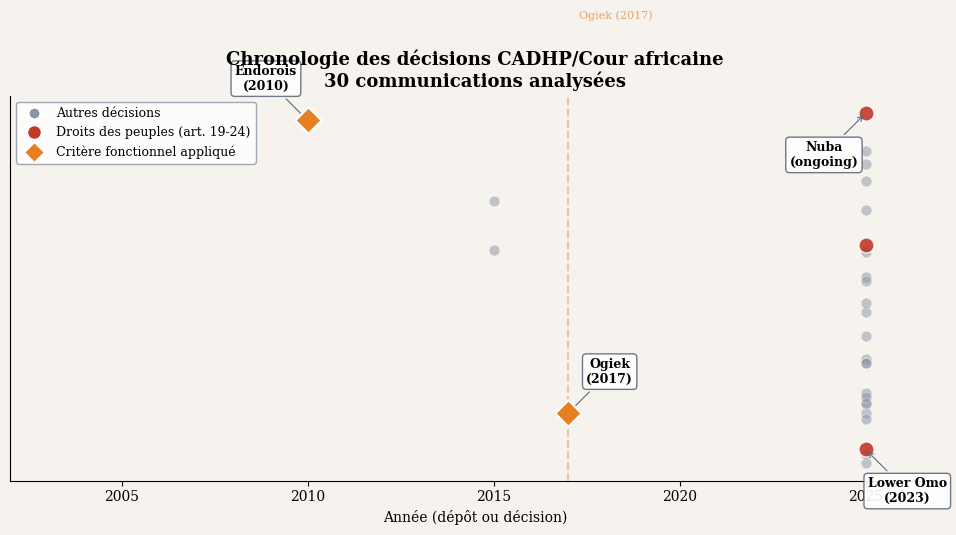

Saved: ch3_case_law_timeline.pdf/png


In [3]:
fig, ax = plt.subplots(figsize=(12, 5))

# Filter out cases with no year
valid = df.dropna(subset=['year']).copy()
valid = valid.sort_values('year')

# Separate peoples' rights cases from others
others = valid[~valid['has_peoples']]
peoples = valid[valid['has_peoples']]

# Jitter y-position for readability
np.random.seed(42)
valid['y'] = np.random.uniform(0.2, 0.8, len(valid))

# Plot regular cases
ax.scatter(others['year'], valid.loc[others.index, 'y'],
           s=60, c=C_DIM, alpha=0.5, zorder=2, edgecolors='white', linewidths=0.5)

# Plot peoples' rights cases (larger, colored)
ax.scatter(peoples['year'], valid.loc[peoples.index, 'y'],
           s=120, c=C_PEOPLES, alpha=0.9, zorder=3, edgecolors='white', linewidths=1)

# Highlight functional criterion cases (diamond marker)
func_cases = valid[valid['has_functional_criterion']]
ax.scatter(func_cases['year'], valid.loc[func_cases.index, 'y'],
           s=180, c=C_FUNC, marker='D', zorder=4, edgecolors='white', linewidths=1.5)

# Annotate key cases
annotations = {
    '276/03': ('Endorois\n(2010)', -30, 30),
    '006/2012': ('Ogiek\n(2017)', 30, 30),
    '419/12': ('Lower Omo\n(2023)', 30, -30),
    '402/11': ('Nuba\n(ongoing)', -30, -30),
}

for _, r in valid.iterrows():
    if r['case_number'] in annotations:
        label, dx, dy = annotations[r['case_number']]
        ax.annotate(label,
                    xy=(r['year'], valid.loc[r.name, 'y']),
                    xytext=(dx, dy), textcoords='offset points',
                    fontsize=9, fontweight='bold',
                    ha='center', va='center',
                    arrowprops=dict(arrowstyle='->', color=C_MUTED, lw=0.8),
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=C_MUTED, alpha=0.9))

# Ogiek vertical line (2017 = turning point)
ax.axvline(x=2017, color=C_FUNC, linestyle='--', alpha=0.4, zorder=1)
ax.text(2017.3, 0.95, 'Ogiek (2017)', fontsize=8, color=C_FUNC, alpha=0.7, va='top')

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=C_DIM, markersize=8, label='Autres décisions'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=C_PEOPLES, markersize=10, label='Droits des peuples (art. 19-24)'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor=C_FUNC, markersize=10, label='Critère fonctionnel appliqué'),
]
ax.legend(handles=legend_elements, loc='upper left', frameon=True, facecolor='white', edgecolor=C_DIM, fontsize=9)

ax.set_xlabel('Année (dépôt ou décision)', fontsize=10)
ax.set_yticks([])
ax.set_title('Chronologie des décisions CADHP/Cour africaine\n30 communications analysées',
             fontsize=13, fontweight='bold', fontfamily='serif')
ax.set_xlim(2002, 2027)

for fmt in ('pdf', 'png'):
    fig.savefig(FIG_DIR / f'ch3_case_law_timeline.{fmt}')
plt.show()
print('Saved: ch3_case_law_timeline.pdf/png')

## 3. Ch.3 — Article Invocation Frequency (Figure 2)

Which articles of the African Charter are most frequently invoked? Peoples' rights articles (19-24) are highlighted.

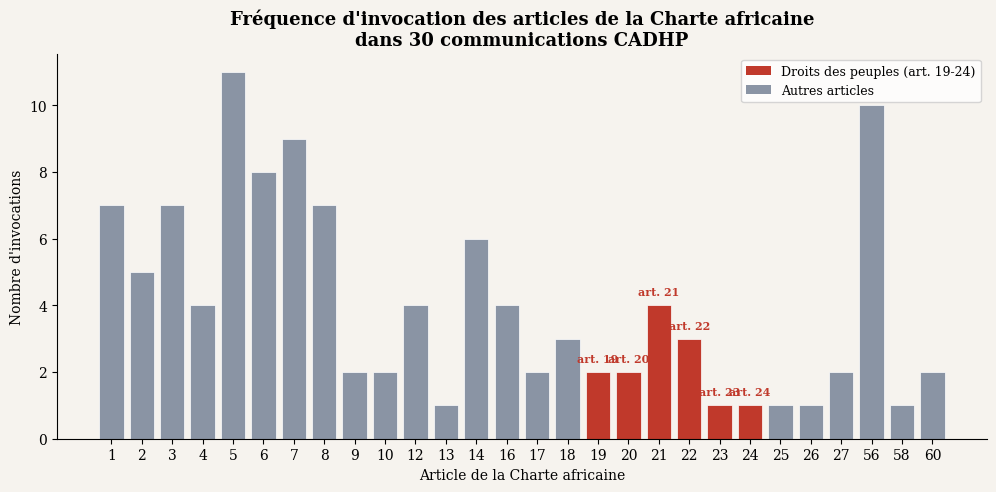

Saved: ch3_article_frequency.pdf/png


In [4]:
# Count article invocations across all cases
art_counter = Counter()
for arts in df['all_articles']:
    for a in arts:
        try:
            art_counter[int(a)] += 1
        except ValueError:
            pass  # skip non-numeric (e.g., empty strings)

# Sort by article number
articles = sorted(art_counter.keys())
counts = [art_counter[a] for a in articles]

# Peoples' rights articles
peoples_arts = {19, 20, 21, 22, 23, 24}
colors = [C_PEOPLES if a in peoples_arts else C_DIM for a in articles]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar([str(a) for a in articles], counts, color=colors, edgecolor='white', linewidth=0.5)

# Label peoples' rights articles
for i, a in enumerate(articles):
    if a in peoples_arts:
        ax.text(i, counts[i] + 0.3, f'art. {a}', ha='center', fontsize=8,
                fontweight='bold', color=C_PEOPLES)

legend_elements = [
    mpatches.Patch(facecolor=C_PEOPLES, label='Droits des peuples (art. 19-24)'),
    mpatches.Patch(facecolor=C_DIM, label='Autres articles'),
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True, facecolor='white', fontsize=9)

ax.set_xlabel('Article de la Charte africaine', fontsize=10)
ax.set_ylabel('Nombre d\'invocations', fontsize=10)
ax.set_title('Fréquence d\'invocation des articles de la Charte africaine\ndans 30 communications CADHP',
             fontsize=13, fontweight='bold', fontfamily='serif')

for fmt in ('pdf', 'png'):
    fig.savefig(FIG_DIR / f'ch3_article_frequency.{fmt}')
plt.show()
print('Saved: ch3_article_frequency.pdf/png')

## 4. Ch.3 — Functional Criterion Emergence (Figure 3)

Timeline focused on the 5 cases that invoke peoples' rights. Shows the progressive construction of the sub-state peoples category through key legal formulations.

> **Thesis argument (Ch.3):** The ACHPR *constructed* the functional criterion progressively — from Endorois (2010, first explicit recognition of indigenous peoples' rights) through Ogiek (2017, African Court confirmation) to Lower Omo (2023, extended application) and Nuba (ongoing, non-indigenous peoples). The criterion shifted from *who groups are* to *what protections their situation requires*.

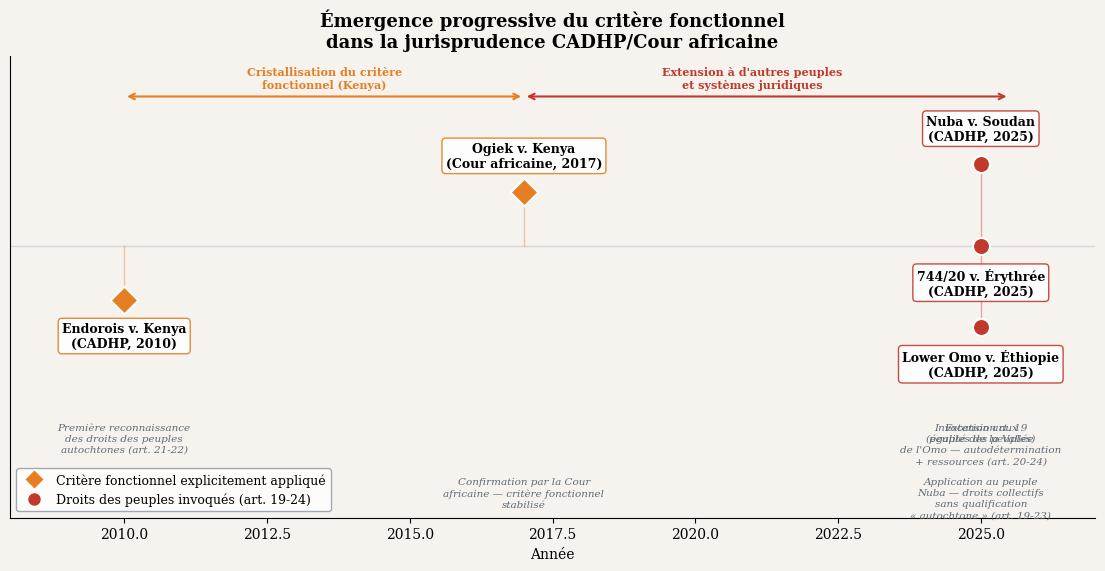

Saved: ch3_functional_criterion_emergence.pdf/png


In [5]:
# Focus on peoples' rights cases + their key formulations
key_cases = [
    {
        'name': 'Endorois v. Kenya',
        'case_number': '276/03',
        'year': 2010,
        'body': 'CADHP',
        'formulation': 'Première reconnaissance\ndes droits des peuples\nautochtones (art. 21-22)',
        'functional': True,
        'articles': [21, 22],
    },
    {
        'name': 'Ogiek v. Kenya',
        'case_number': '006/2012',
        'year': 2017,
        'body': 'Cour africaine',
        'formulation': 'Confirmation par la Cour\nafricaine — critère fonctionnel\nstabilisé',
        'functional': True,
        'articles': [21, 22],
    },
    {
        'name': 'Lower Omo v. Éthiopie',
        'case_number': '419/12',
        'year': 2025,  # decision year from session
        'body': 'CADHP',
        'formulation': 'Extension aux\npeuples de la Vallée\nde l\'Omo — autodétermination\n+ ressources (art. 20-24)',
        'functional': False,  # as coded
        'articles': [20, 21, 22, 24],
    },
    {
        'name': 'Nuba v. Soudan',
        'case_number': '402/11',
        'year': 2025,  # decision year from session
        'body': 'CADHP',
        'formulation': 'Application au peuple\nNuba — droits collectifs\nsans qualification\n« autochtone » (art. 19-23)',
        'functional': False,  # as coded, but important
        'articles': [19, 20, 21, 23],
    },
    {
        'name': '744/20 v. Érythrée',
        'case_number': '744/20',
        'year': 2025,
        'body': 'CADHP',
        'formulation': 'Invocation art. 19\n(égalité des peuples)',
        'functional': False,
        'articles': [19],
    },
]

fig, ax = plt.subplots(figsize=(14, 6))

# Timeline axis
years = [c['year'] for c in key_cases]
y_positions = [0.3, 0.7, 0.2, 0.8, 0.5]  # stagger for readability

# Draw timeline line
ax.axhline(y=0.5, color=C_DIM, linewidth=1, alpha=0.3, zorder=1)

for i, c in enumerate(key_cases):
    color = C_FUNC if c['functional'] else C_PEOPLES
    marker = 'D' if c['functional'] else 'o'
    size = 200 if c['functional'] else 150
    
    # Draw vertical connector
    ax.plot([c['year'], c['year']], [0.5, y_positions[i]], 
            color=color, linewidth=1, alpha=0.4, zorder=1)
    
    # Plot marker
    ax.scatter(c['year'], y_positions[i], s=size, c=color, marker=marker,
              zorder=3, edgecolors='white', linewidths=1.5)
    
    # Label
    offset_y = 0.08 if y_positions[i] > 0.5 else -0.08
    va = 'bottom' if y_positions[i] > 0.5 else 'top'
    
    # Case name
    ax.text(c['year'], y_positions[i] + offset_y,
            f"{c['name']}\n({c['body']}, {c['year']})",
            ha='center', va=va, fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=0.9))

# Add formulation boxes below timeline
for i, c in enumerate(key_cases):
    color = C_FUNC if c['functional'] else C_PEOPLES
    text_y = -0.15 if i % 2 == 0 else -0.35
    ax.text(c['year'], text_y, c['formulation'],
            ha='center', va='top', fontsize=7.5, color=C_MUTED,
            style='italic', linespacing=1.3)

# Phase annotations
ax.annotate('', xy=(2017, 1.05), xytext=(2010, 1.05),
            arrowprops=dict(arrowstyle='<->', color=C_FUNC, lw=1.5))
ax.text(2013.5, 1.08, 'Cristallisation du critère\nfonctionnel (Kenya)',
        ha='center', fontsize=8, color=C_FUNC, fontweight='bold')

ax.annotate('', xy=(2025.5, 1.05), xytext=(2017, 1.05),
            arrowprops=dict(arrowstyle='<->', color=C_PEOPLES, lw=1.5))
ax.text(2021, 1.08, 'Extension à d\'autres peuples\net systèmes juridiques',
        ha='center', fontsize=8, color=C_PEOPLES, fontweight='bold')

# Legend
legend_elements = [
    Line2D([0], [0], marker='D', color='w', markerfacecolor=C_FUNC, markersize=10,
           label='Critère fonctionnel explicitement appliqué'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=C_PEOPLES, markersize=10,
           label='Droits des peuples invoqués (art. 19-24)'),
]
ax.legend(handles=legend_elements, loc='lower left', frameon=True, facecolor='white',
          edgecolor=C_DIM, fontsize=9)

ax.set_xlim(2008, 2027)
ax.set_ylim(-0.5, 1.2)
ax.set_yticks([])
ax.set_xlabel('Année', fontsize=10)
ax.set_title('Émergence progressive du critère fonctionnel\ndans la jurisprudence CADHP/Cour africaine',
             fontsize=13, fontweight='bold', fontfamily='serif')

for fmt in ('pdf', 'png'):
    fig.savefig(FIG_DIR / f'ch3_functional_criterion_emergence.{fmt}')
plt.show()
print('Saved: ch3_functional_criterion_emergence.pdf/png')

## 5. Ch.4 S1 — Doctrinal Concept Frequency (Figure 4)

Which doctrinal concepts appear in the case law corpus? The thesis argues that the ACHPR does NOT use the thesis's theoretical vocabulary.

/tmp/ipykernel_62514/2136050542.py:51: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) DejaVu Serif.
  fig.savefig(FIG_DIR / f'ch4s1_doctrinal_concepts.{fmt}')
/tmp/ipykernel_62514/2136050542.py:51: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) DejaVu Serif.
  fig.savefig(FIG_DIR / f'ch4s1_doctrinal_concepts.{fmt}')


/home/victo/projects/africa-constitutions/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)


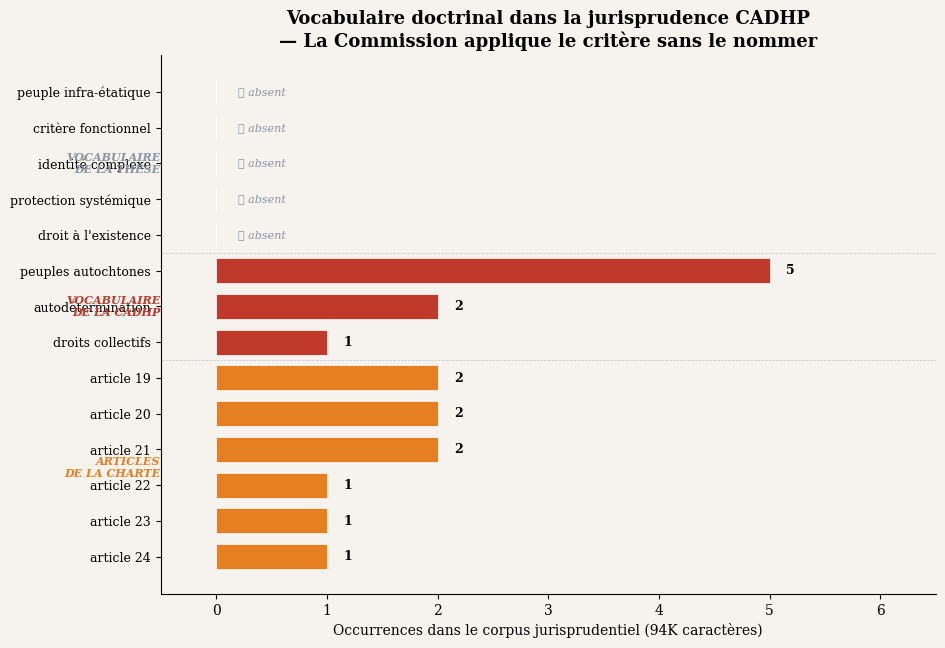

Saved: ch4s1_doctrinal_concepts.pdf/png


In [6]:
concepts = analysis['doctrinal_concepts']

# Separate into thesis vocabulary (absent) and ACHPR vocabulary (present)
thesis_vocab = ['peuple infra-étatique', 'critère fonctionnel', 'identité complexe',
                'protection systémique', 'droit à l\'existence']
charter_articles = ['article 19', 'article 20', 'article 21', 'article 22', 'article 23', 'article 24']
other_concepts = ['peuples autochtones', 'autodétermination', 'droits collectifs']

# Build ordered list: thesis vocab first (all zero), then ACHPR vocab
all_concepts = thesis_vocab + other_concepts + charter_articles
counts = [concepts.get(c, {}).get('count', 0) for c in all_concepts]
colors_bar = ([C_DIM] * len(thesis_vocab) + 
              [C_PEOPLES] * len(other_concepts) + 
              [C_FUNC] * len(charter_articles))

fig, ax = plt.subplots(figsize=(10, 7))

y_pos = range(len(all_concepts))
bars = ax.barh(y_pos, counts, color=colors_bar, edgecolor='white', linewidth=0.5, height=0.7)

ax.set_yticks(y_pos)
ax.set_yticklabels(all_concepts, fontsize=9)
ax.invert_yaxis()

# Add count labels
for i, (count, concept) in enumerate(zip(counts, all_concepts)):
    if count == 0:
        ax.text(0.2, i, '✗ absent', fontsize=8, color=C_DIM, va='center', style='italic')
    else:
        ax.text(count + 0.15, i, str(count), fontsize=9, va='center', fontweight='bold')

# Separator lines
ax.axhline(y=len(thesis_vocab) - 0.5, color=C_DIM, linewidth=0.5, linestyle='--', alpha=0.5)
ax.axhline(y=len(thesis_vocab) + len(other_concepts) - 0.5, color=C_DIM, linewidth=0.5, linestyle='--', alpha=0.5)

# Group labels
ax.text(-0.5, 2, 'VOCABULAIRE\nDE LA THÈSE', fontsize=8, color=C_DIM, fontweight='bold',
        ha='right', va='center', style='italic')
ax.text(-0.5, len(thesis_vocab) + 1, 'VOCABULAIRE\nDE LA CADHP', fontsize=8, color=C_PEOPLES, fontweight='bold',
        ha='right', va='center', style='italic')
ax.text(-0.5, len(thesis_vocab) + len(other_concepts) + 2.5, 'ARTICLES\nDE LA CHARTE', fontsize=8, color=C_FUNC, fontweight='bold',
        ha='right', va='center', style='italic')

ax.set_xlabel('Occurrences dans le corpus jurisprudentiel (94K caractères)', fontsize=10)
ax.set_title('Vocabulaire doctrinal dans la jurisprudence CADHP\n— La Commission applique le critère sans le nommer',
             fontsize=13, fontweight='bold', fontfamily='serif')

ax.set_xlim(-0.5, max(counts) + 1.5)

for fmt in ('pdf', 'png'):
    fig.savefig(FIG_DIR / f'ch4s1_doctrinal_concepts.{fmt}')
plt.show()
print('Saved: ch4s1_doctrinal_concepts.pdf/png')

## 6. Ch.4 S2 — Cross-System Citations (Figure 5)

The ACHPR cites other international systems via articles 60-61 of the Charter. Which systems does it draw from?

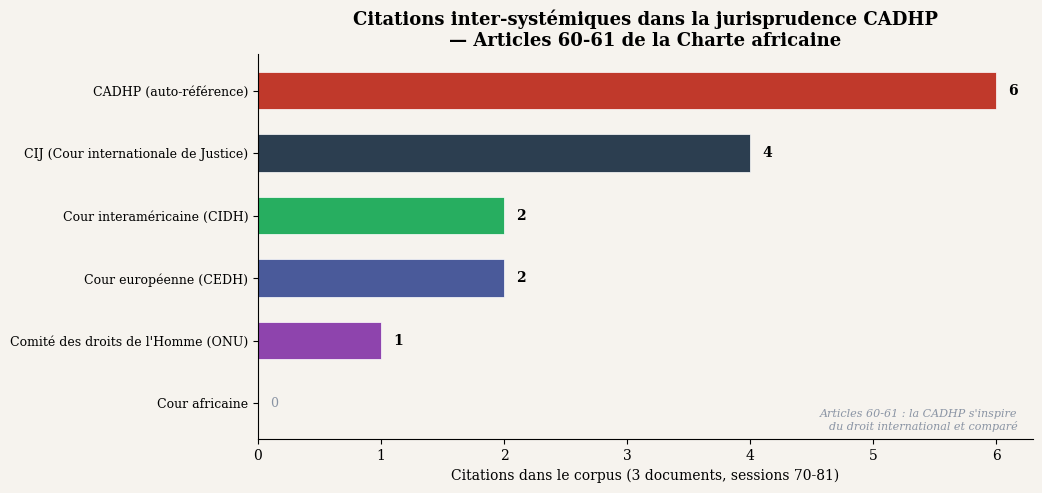

Saved: ch4s2_cross_system_citations.pdf/png


In [7]:
citations = analysis['cross_system_citations']

# Order by count
systems = sorted(citations.keys(), key=lambda s: citations[s]['count'], reverse=True)
counts_cit = [citations[s]['count'] for s in systems]

# Color by system type
system_colors = {
    'ACHPR/CADHP': C_PEOPLES,
    'ICJ/CIJ': '#2c3e50',
    'Inter-American (IACHR/CIDH)': '#27ae60',
    'European (ECHR/CEDH)': C_FRANCO,
    'UN HRC': '#8e44ad',
    'African Court': C_FUNC,
}
colors_cit = [system_colors.get(s, C_DIM) for s in systems]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(range(len(systems)), counts_cit, color=colors_cit, edgecolor='white', linewidth=0.5, height=0.6)

# Clean labels
labels = {
    'ACHPR/CADHP': 'CADHP (auto-référence)',
    'ICJ/CIJ': 'CIJ (Cour internationale de Justice)',
    'Inter-American (IACHR/CIDH)': 'Cour interaméricaine (CIDH)',
    'European (ECHR/CEDH)': 'Cour européenne (CEDH)',
    'UN HRC': 'Comité des droits de l\'Homme (ONU)',
    'African Court': 'Cour africaine',
}

ax.set_yticks(range(len(systems)))
ax.set_yticklabels([labels.get(s, s) for s in systems], fontsize=9)
ax.invert_yaxis()

# Count labels
for i, count in enumerate(counts_cit):
    if count > 0:
        ax.text(count + 0.1, i, str(count), fontsize=10, va='center', fontweight='bold')
    else:
        ax.text(0.1, i, '0', fontsize=9, va='center', color=C_DIM)

ax.set_xlabel('Citations dans le corpus (3 documents, sessions 70-81)', fontsize=10)
ax.set_title('Citations inter-systémiques dans la jurisprudence CADHP\n— Articles 60-61 de la Charte africaine',
             fontsize=13, fontweight='bold', fontfamily='serif')

# Add explanatory note
ax.text(0.98, 0.02,
        'Articles 60-61 : la CADHP s\'inspire\ndu droit international et comparé',
        transform=ax.transAxes, fontsize=8, color=C_DIM, style='italic',
        ha='right', va='bottom')

for fmt in ('pdf', 'png'):
    fig.savefig(FIG_DIR / f'ch4s2_cross_system_citations.{fmt}')
plt.show()
print('Saved: ch4s2_cross_system_citations.pdf/png')

## 7. Ch.3/Ch.4 — Landmark Case Citation Network (Figure 6)

Which landmark cases are cited within the corpus? The Nuba case dominates.

/tmp/ipykernel_62514/477688360.py:36: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) DejaVu Serif.
  fig.savefig(FIG_DIR / f'ch4_landmark_citations.{fmt}')
/tmp/ipykernel_62514/477688360.py:36: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) DejaVu Serif.
  fig.savefig(FIG_DIR / f'ch4_landmark_citations.{fmt}')


/home/victo/projects/africa-constitutions/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)


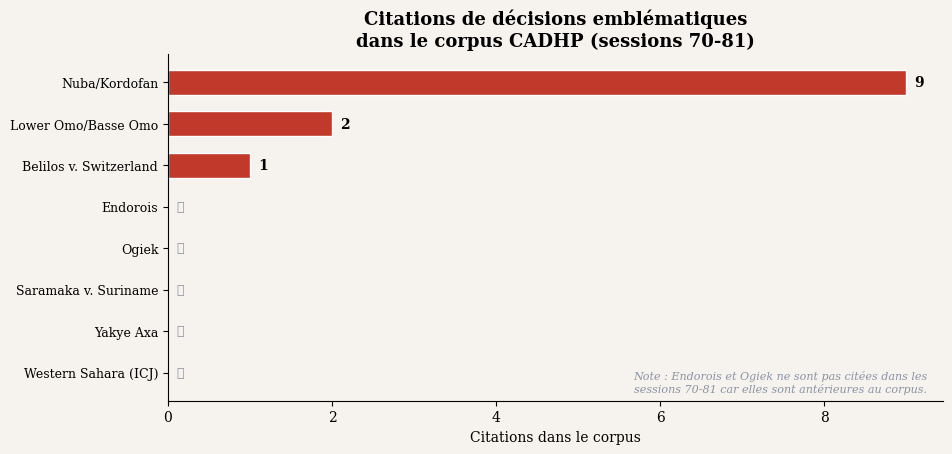

Saved: ch4_landmark_citations.pdf/png


In [8]:
landmarks = analysis['landmark_case_citations']

# Filter to non-zero and sort
cited = {k: v for k, v in landmarks.items() if v > 0}
uncited = {k: v for k, v in landmarks.items() if v == 0}

# All landmarks ordered by count
all_lm = sorted(landmarks.keys(), key=lambda k: landmarks[k], reverse=True)
lm_counts = [landmarks[k] for k in all_lm]
lm_colors = [C_PEOPLES if landmarks[k] > 0 else C_DIM for k in all_lm]

fig, ax = plt.subplots(figsize=(10, 4.5))

bars = ax.barh(range(len(all_lm)), lm_counts, color=lm_colors, edgecolor='white', height=0.6)
ax.set_yticks(range(len(all_lm)))
ax.set_yticklabels(all_lm, fontsize=9)
ax.invert_yaxis()

for i, count in enumerate(lm_counts):
    if count > 0:
        ax.text(count + 0.1, i, str(count), fontsize=10, va='center', fontweight='bold')
    else:
        ax.text(0.1, i, '✗', fontsize=9, va='center', color=C_DIM)

ax.set_xlabel('Citations dans le corpus', fontsize=10)
ax.set_title('Citations de décisions emblématiques\ndans le corpus CADHP (sessions 70-81)',
             fontsize=13, fontweight='bold', fontfamily='serif')

# Note about Endorois/Ogiek absence
ax.text(0.98, 0.02,
        'Note : Endorois et Ogiek ne sont pas citées dans les\nsessions 70-81 car elles sont antérieures au corpus.',
        transform=ax.transAxes, fontsize=8, color=C_DIM, style='italic',
        ha='right', va='bottom')

for fmt in ('pdf', 'png'):
    fig.savefig(FIG_DIR / f'ch4_landmark_citations.{fmt}')
plt.show()
print('Saved: ch4_landmark_citations.pdf/png')

## 8. Ch.5 — Pre/Post-Ogiek Constitutional Evolution

Does the Ogiek decision (2017) correlate with changes in constitutional recognition? We compare constitutions adopted before vs after 2017 across the 10 dimensions.

> **Caveat:** This is a cross-sectional comparison (not causal). Few constitutions were adopted after 2017 in our dataset. The Ogiek effect, if any, would manifest in future constitutional revisions.

In [9]:
features = DATA['features']
feature_labels = DATA['feature_labels']
heritage = DATA['colonial_heritage']
timelines = DATA['country_timelines']

# Score mapping: timeline features are stored as strings (X/P/V)
score_map = {'X': 0, 'P': 1, 'V': 2, 0: 0, 1: 1, 2: 2}

# Get the most recent constitution for each country, split by pre/post 2017
pre_ogiek = []   # constitutions adopted before 2017
post_ogiek = []  # constitutions adopted 2017 or later

for country, entries in timelines.items():
    if country == 'République sahraouie':
        continue
    # Get the most recent entry with feature data
    coded = [e for e in entries if e.get('has_feature_data')]
    if not coded:
        continue
    latest = max(coded, key=lambda e: e['year'])
    record = {f: score_map.get(latest['features'].get(f, 'X'), 0) for f in features}
    record['country'] = country
    record['year'] = latest['year']
    record['heritage'] = heritage.get(country, 'unknown')
    record['total'] = sum(record[f] for f in features)

    if latest['year'] < 2017:
        pre_ogiek.append(record)
    else:
        post_ogiek.append(record)

print(f'Constitutions pre-Ogiek (before 2017): {len(pre_ogiek)}')
print(f'Constitutions post-Ogiek (2017+): {len(post_ogiek)}')

if post_ogiek:
    print(f'\nPost-Ogiek countries:')
    for r in sorted(post_ogiek, key=lambda x: x['year']):
        print(f'  {r["country"]} ({r["year"]}, {r["heritage"]}): total={r["total"]}')

# Compute mean scores per dimension
pre_means = {f: np.mean([r[f] for r in pre_ogiek]) for f in features}
post_means = {f: np.mean([r[f] for r in post_ogiek]) for f in features} if post_ogiek else {}

print(f'\nPre-Ogiek mean total: {np.mean([r["total"] for r in pre_ogiek]):.1f}')
if post_ogiek:
    print(f'Post-Ogiek mean total: {np.mean([r["total"] for r in post_ogiek]):.1f}')


Constitutions pre-Ogiek (before 2017): 40
Constitutions post-Ogiek (2017+): 14

Post-Ogiek countries:
  Mauritanie (2017, francophone): total=6
  Burundi (2018, francophone): total=11
  Comores (2018, francophone): total=10
  Mozambique (2018, lusophone): total=9
  Soudan (2019, anglophone): total=11
  Algérie (2020, francophone): total=8
  Guinée (2021, francophone): total=3
  Tunisie (2022, francophone): total=3
  Mali (2023, francophone): total=10
  République centrafricaine (2023, francophone): total=8
  Tchad (2023, francophone): total=10
  Burkina Faso (2024, francophone): total=9
  Gabon (2024, francophone): total=5
  Togo (2024, francophone): total=6

Pre-Ogiek mean total: 9.2
Post-Ogiek mean total: 7.8


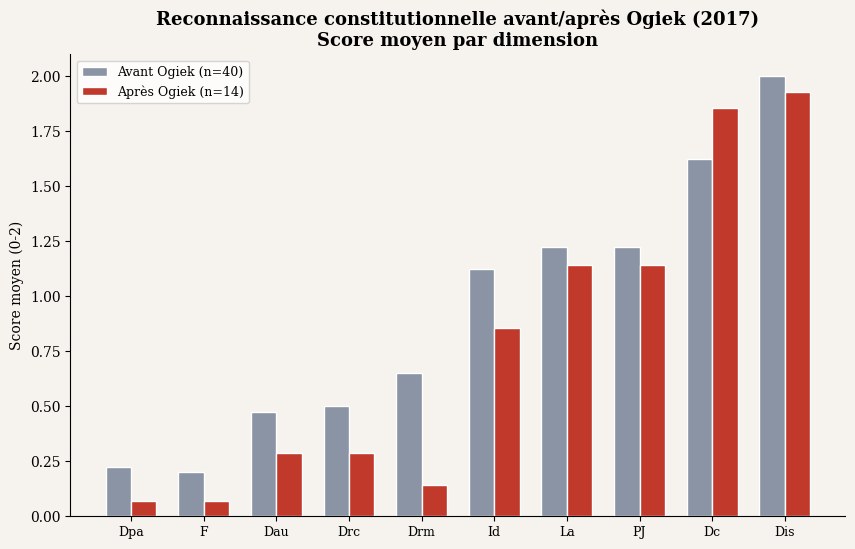

Saved: ch5_pre_post_ogiek.pdf/png


In [10]:
# Figure 7: Pre vs Post-Ogiek comparison
if post_ogiek and len(post_ogiek) >= 3:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x = np.arange(len(features))
    width = 0.35
    
    pre_vals = [pre_means[f] for f in features]
    post_vals = [post_means[f] for f in features]
    
    bars1 = ax.bar(x - width/2, pre_vals, width, label=f'Avant Ogiek (n={len(pre_ogiek)})',
                   color=C_DIM, edgecolor='white')
    bars2 = ax.bar(x + width/2, post_vals, width, label=f'Après Ogiek (n={len(post_ogiek)})',
                   color=C_PEOPLES, edgecolor='white')
    
    ax.set_xticks(x)
    ax.set_xticklabels(features, fontsize=9)
    ax.set_ylabel('Score moyen (0-2)', fontsize=10)
    ax.legend(frameon=True, facecolor='white', fontsize=9)
    ax.set_title('Reconnaissance constitutionnelle avant/après Ogiek (2017)\nScore moyen par dimension',
                 fontsize=13, fontweight='bold', fontfamily='serif')
    
    for fmt in ('pdf', 'png'):
        fig.savefig(FIG_DIR / f'ch5_pre_post_ogiek.{fmt}')
    plt.show()
    print('Saved: ch5_pre_post_ogiek.pdf/png')
else:
    n_post = len(post_ogiek) if post_ogiek else 0
    print(f'Only {n_post} constitutions adopted after Ogiek (2017).')
    print('Too few for a meaningful comparison figure.')
    print('This is itself a finding: the Ogiek effect, if any, has not yet materialized')
    print('in constitutional revisions — consistent with the thesis argument that')
    print('ACHPR case law constructs the category but constitutional recognition')
    print('depends on domestic political moments (post-conflict).')

## 9. Summary

Key findings from the case law analysis.

In [11]:
print('=' * 60)
print('M3/M5 CASE LAW ANALYSIS — SUMMARY')
print('=' * 60)

print(f'\n--- Dataset ---')
print(f'Total cases analyzed: {len(df)}')
print(f'Cases invoking peoples\' rights (art. 19-24): {df["has_peoples"].sum()}/30')
print(f'Cases with functional criterion: {df["has_functional_criterion"].sum()}/30')
print(f'Cases referencing "autochtone": {df["has_autochtone"].sum()}/30')
print(f'Cases mentioning self-determination: {df["has_self_determination"].sum()}/30')

print(f'\n--- Ch.3: Functional Criterion Emergence ---')
print(f'Endorois (2010): first ACHPR recognition of indigenous peoples\' rights')
print(f'Ogiek (2017): African Court confirmation — criterion stabilized')
print(f'Lower Omo (2025): extension to Omo Valley peoples + self-determination')
print(f'Nuba (2025): applied to non-indigenous peoples (no "autochtone" label)')
print(f'→ Progressive shift from WHO groups are to WHAT protections they need')

print(f'\n--- Ch.4 S1: Doctrinal Concepts ---')
print(f'Thesis vocabulary ABSENT: peuple infra-étatique, critère fonctionnel,')
print(f'  identité complexe, protection systémique, droit à l\'existence')
print(f'ACHPR vocabulary PRESENT: peuples autochtones (5), autodétermination (2),')
print(f'  droits collectifs (1)')
print(f'→ The thesis CONSTRUCTS the category; the Commission APPLIES it without naming it')

print(f'\n--- Ch.4 S2: Cross-System Citations ---')
for s in sorted(citations.keys(), key=lambda k: citations[k]['count'], reverse=True):
    print(f'  {s}: {citations[s]["count"]} citations')
print(f'→ CIJ dominates (4), followed by CADHP auto-reference (6 incl. own jurisprudence)')
print(f'→ Inter-American and European cited (2 each) — articles 60-61 in action')
print(f'→ African Court: 0 citations (corpus covers ACHPR only, not Court decisions)')

print(f'\n--- Ch.5: Pre/Post-Ogiek ---')
n_post = len(post_ogiek) if post_ogiek else 0
print(f'Constitutions adopted after Ogiek (2017): {n_post}')
if n_post < 5:
    print(f'→ Too few for statistical comparison. The Ogiek effect has not yet')
    print(f'  materialized in constitutional text. This supports the thesis:')
    print(f'  case law constructs the category, but constitutional recognition')
    print(f'  depends on domestic political moments (post-conflict).')

print(f'\n--- Figures Generated ---')
import glob
figs = sorted(glob.glob(str(FIG_DIR / 'ch3_*'))) + sorted(glob.glob(str(FIG_DIR / 'ch4*')))
for f in figs:
    print(f'  {Path(f).name}')
if n_post >= 3:
    print(f'  ch5_pre_post_ogiek.pdf/png')

print(f'\n--- Caveats ---')
print(f'1. Dataset is NOT exhaustive (30/~200+ ACHPR decisions)')
print(f'2. Functional criterion coding is preliminary (requires Alex\'s validation)')
print(f'3. Dates are mixed (filing year vs decision date vs session date)')
print(f'4. Cross-system citations only from 3 docx files (sessions 70-81)')

M3/M5 CASE LAW ANALYSIS — SUMMARY

--- Dataset ---
Total cases analyzed: 30
Cases invoking peoples' rights (art. 19-24): 5/30
Cases with functional criterion: 2/30
Cases referencing "autochtone": 3/30
Cases mentioning self-determination: 1/30

--- Ch.3: Functional Criterion Emergence ---
Endorois (2010): first ACHPR recognition of indigenous peoples' rights
Ogiek (2017): African Court confirmation — criterion stabilized
Lower Omo (2025): extension to Omo Valley peoples + self-determination
Nuba (2025): applied to non-indigenous peoples (no "autochtone" label)
→ Progressive shift from WHO groups are to WHAT protections they need

--- Ch.4 S1: Doctrinal Concepts ---
Thesis vocabulary ABSENT: peuple infra-étatique, critère fonctionnel,
  identité complexe, protection systémique, droit à l'existence
ACHPR vocabulary PRESENT: peuples autochtones (5), autodétermination (2),
  droits collectifs (1)
→ The thesis CONSTRUCTS the category; the Commission APPLIES it without naming it

--- Ch.4 S2: